In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_15164\2467916011.py:31: SyntaxWarning: invalid escape sequence '\l'
  label=f'Minimum: $\lambda^*={lambda_star:.2f}, MFPT={mfpt_star:.2f}$')
C:\Users\bartik\AppData\Local\Temp\ipykernel_15164\2467916011.py:39: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Theoretical Optimal Resetting Rate (lambda*): 2.5396
Theoretical Minimum MFPT: 1.5441


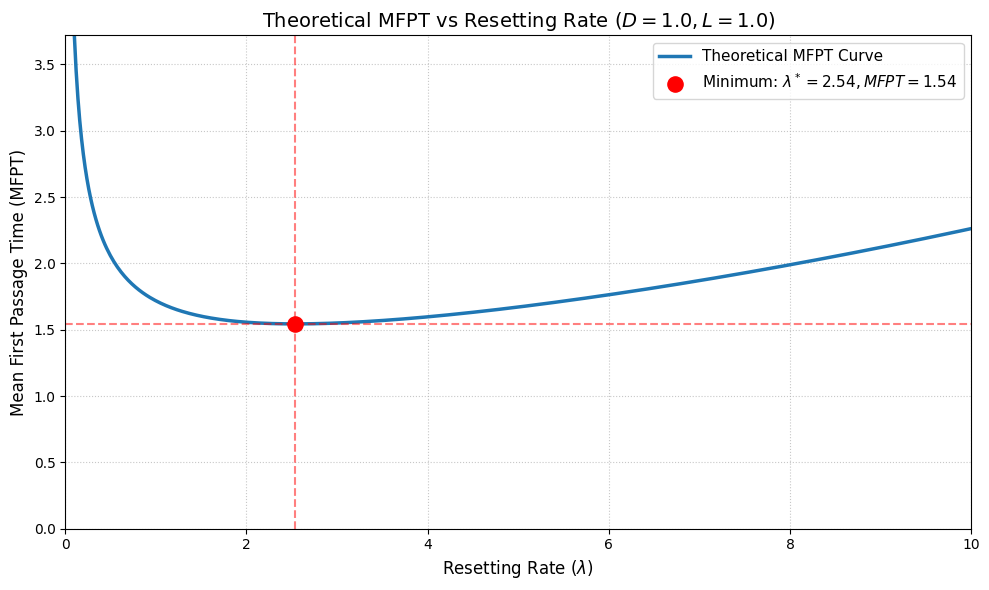

In [2]:
# --- 1. Set System Parameters ---
D = 1.0  # Diffusion coefficient
L = 1.0  # Distance to the absorbing target

# --- 2. Define the Theoretical MFPT Function ---
def theoretical_mfpt(lam, D, L):
    """Calculates the theoretical MFPT for a given lambda."""
    # We use np.where to handle lambda = 0 safely if it's in the array, 
    # though mathematically it approaches infinity.
    return np.where(lam == 0, np.inf, (1 / lam) * (np.exp(np.sqrt(lam / D) * L) - 1))
z = 1.593624 
lambda_star = D * (z / L)**2
mfpt_star = theoretical_mfpt(lambda_star, D, L)

print(f"Theoretical Optimal Resetting Rate (lambda*): {lambda_star:.4f}")
print(f"Theoretical Minimum MFPT: {mfpt_star:.4f}")

# --- 4. Generate Data for the Curve ---
# Create an array of lambda values from 0.1 up to 10
lambda_vals = np.linspace(0.1, 10.0, 500)
mfpt_vals = theoretical_mfpt(lambda_vals, D, L)

# --- 5. Plotting ---
plt.figure(figsize=(10, 6))

# Plot the main U-shaped curve
plt.plot(lambda_vals, mfpt_vals, color='#1f77b4', linewidth=2.5, label='Theoretical MFPT Curve')

# Highlight the optimal minimum point
plt.scatter(lambda_star, mfpt_star, color='red', s=120, zorder=5, 
            label=f'Minimum: $\lambda^*={lambda_star:.2f}, MFPT={mfpt_star:.2f}$')

# Add dashed guide lines to the axes for clarity
plt.axvline(x=lambda_star, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=mfpt_star, color='red', linestyle='--', alpha=0.5)

# Formatting
plt.title(f'Theoretical MFPT vs Resetting Rate ($D={D}, L={L}$)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)
plt.ylim(0, max(mfpt_vals[0], mfpt_vals[-1])) # Keep the y-axis bounded nicely
plt.xlim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

# Show the plot
plt.show()

<>:86: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_15164\2648486172.py:86: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Rozpoczynam symulację dla 20 punktów. Proszę czekać...
Ukończono: 100% (20/20 punktów)
Symulacja zakończona!
------------------------------
SIMULATION QUALITY METRICS
MAPE: 2.1517%
RMSE: 0.047852
------------------------------


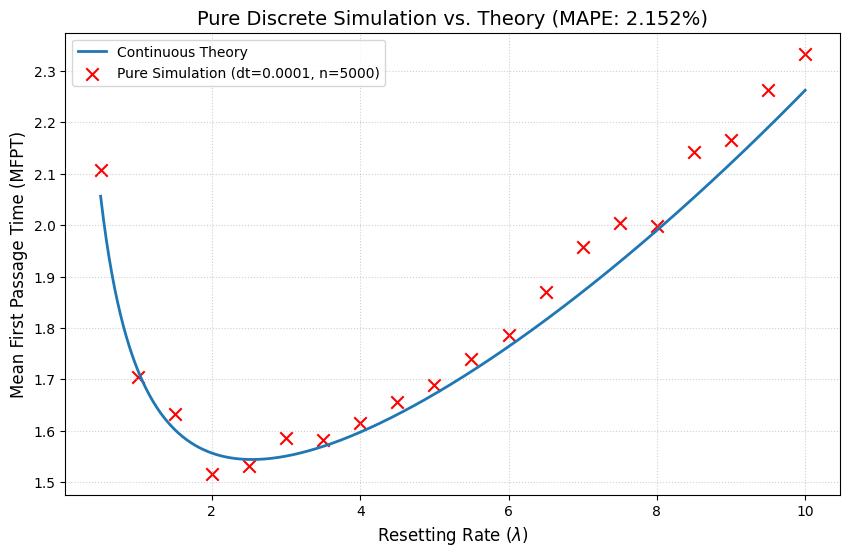

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --- 1. Set System Parameters ---
D = 1.0
L = 1.0
dt = 1e-4      # Lowered dt to minimize boundary overshoot bias
num_trials = 5000   # Massively increased trials to crush statistical noise

@njit
def simulate_mfpt_pure(lam, D, L, dt, trials):
    """
    Pure numerical MFPT without boundary corrections.
    """
    if lam <= 0: 
        return np.nan
    
    total_fpt = 0.0
    sqrt_2Ddt = np.sqrt(2 * D * dt)
    
    # Exact discrete probability of a reset occurring within dt
    p_reset = 1.0 - np.exp(-lam * dt) 
    
    for _ in range(trials):
        x = 0.0
        t = 0.0
        while x < L:
            # 1. Stochastic Resetting
            if np.random.random() < p_reset:
                x = 0.0
            else:
                # 2. Diffusion step
                x += np.random.normal(0, 1.0) * sqrt_2Ddt
            
            t += dt
            
            # Safety break
            if t > 500: 
                break
        total_fpt += t
        
    return total_fpt / trials

# --- 2. Generate Comparison Data ---
sim_lambda_vals = np.linspace(0.5, 10, 20)
total_points = len(sim_lambda_vals)
print(f"Rozpoczynam symulację dla {total_points} punktów. Proszę czekać...")

# Pusta tablica na wyniki
sim_results = np.zeros(total_points)

# Pętla z wskaźnikiem postępu
for i, l in enumerate(sim_lambda_vals):
    sim_results[i] = simulate_mfpt_pure(l, D, L, dt, num_trials)
    
    # Obliczanie i wyświetlanie procentu w tej samej linijce
    procent = ((i + 1) / total_points) * 100
    print(f"\rUkończono: {procent:.0f}% ({i + 1}/{total_points} punktów)", end="", flush=True)

print("\nSymulacja zakończona!") # Nowa linia po zakończeniu odliczania

# Calculate exact theoretical values at the same lambda points
theory_at_sim = (1 / sim_lambda_vals) * (np.exp(np.sqrt(sim_lambda_vals / D) * L) - 1)

# --- 3. Calculate Error Metrics ---
mape = np.mean(np.abs((theory_at_sim - sim_results) / theory_at_sim)) * 100
rmse = np.sqrt(np.mean((theory_at_sim - sim_results)**2))

print("-" * 30)
print(f"SIMULATION QUALITY METRICS")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.6f}")
print("-" * 30)

# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
lam_theory_fine = np.linspace(0.5, 10, 500)
mfpt_theory_fine = (1 / lam_theory_fine) * (np.exp(np.sqrt(lam_theory_fine / D) * L) - 1)

plt.plot(lam_theory_fine, mfpt_theory_fine, label='Continuous Theory', color='#1f77b4', lw=2)
plt.scatter(sim_lambda_vals, sim_results, color='red', marker='x', s=80, 
            label=f'Pure Simulation (dt={dt}, n={num_trials})')

plt.title(f'Pure Discrete Simulation vs. Theory (MAPE: {mape:.3f}%)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [4]:
min_idx = np.argmin(sim_results)
lambda_opt_sim = sim_lambda_vals[min_idx]
min_mfpt_sim = sim_results[min_idx]

print(f"Numeryczne optimum lambda: {lambda_opt_sim:.3f} (MFPT = {min_mfpt_sim:.3f})")

Numeryczne optimum lambda: 2.000 (MFPT = 1.516)


In [6]:
from scipy.optimize import minimize_scalar

# Funkcja teoretyczna zdefiniowana dla optymalizatora
def theory_mfpt_scalar(lam, D=1.0, L=1.0):
    return (1 / lam) * (np.exp(np.sqrt(lam / D) * L) - 1)

# Szukamy minimum w przedziale od 0.1 do 10
res = minimize_scalar(theory_mfpt_scalar, bounds=(0.1, 10), method='bounded')
lambda_opt_theory = res.x
min_mfpt_theory = res.fun

print(f"Teoretyczne optimum lambda: {lambda_opt_theory:.4f} (MFPT = {min_mfpt_theory:.4f})")

Teoretyczne optimum lambda: 2.5396 (MFPT = 1.5441)


<>:86: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\l'
C:\Users\bartik\AppData\Local\Temp\ipykernel_15164\83688113.py:86: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)


Rozpoczynam symulację dla 30 punktów. Proszę czekać...
Ukończono: 100% (30/30 punktów)
Symulacja zakończona!
------------------------------
SIMULATION QUALITY METRICS
MAPE: 1.6327%
RMSE: 0.031274
------------------------------


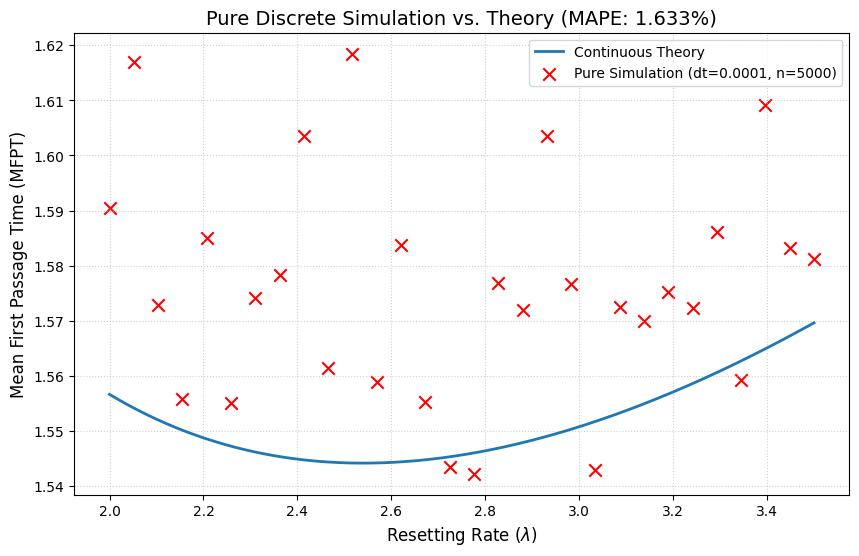

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# --- 1. Set System Parameters ---
D = 1.0
L = 1.0
dt = 1e-4      # Lowered dt to minimize boundary overshoot bias
num_trials = 5000   # Massively increased trials to crush statistical noise

@njit
def simulate_mfpt_pure(lam, D, L, dt, trials):
    """
    Pure numerical MFPT without boundary corrections.
    """
    if lam <= 0: 
        return np.nan
    
    total_fpt = 0.0
    sqrt_2Ddt = np.sqrt(2 * D * dt)
    
    # Exact discrete probability of a reset occurring within dt
    p_reset = 1.0 - np.exp(-lam * dt) 
    
    for _ in range(trials):
        x = 0.0
        t = 0.0
        while x < L:
            # 1. Stochastic Resetting
            if np.random.random() < p_reset:
                x = 0.0
            else:
                # 2. Diffusion step
                x += np.random.normal(0, 1.0) * sqrt_2Ddt
            
            t += dt
            
            # Safety break
            if t > 500: 
                break
        total_fpt += t
        
    return total_fpt / trials

# --- 2. Generate Comparison Data ---
sim_lambda_vals = np.linspace(2.0, 3.5, 30) # Wąski zakres, dużo punktów
total_points = len(sim_lambda_vals)
print(f"Rozpoczynam symulację dla {total_points} punktów. Proszę czekać...")

# Pusta tablica na wyniki
sim_results = np.zeros(total_points)

# Pętla z wskaźnikiem postępu
for i, l in enumerate(sim_lambda_vals):
    sim_results[i] = simulate_mfpt_pure(l, D, L, dt, num_trials)
    
    # Obliczanie i wyświetlanie procentu w tej samej linijce
    procent = ((i + 1) / total_points) * 100
    print(f"\rUkończono: {procent:.0f}% ({i + 1}/{total_points} punktów)", end="", flush=True)

print("\nSymulacja zakończona!") # Nowa linia po zakończeniu odliczania

# Calculate exact theoretical values at the same lambda points
theory_at_sim = (1 / sim_lambda_vals) * (np.exp(np.sqrt(sim_lambda_vals / D) * L) - 1)

# --- 3. Calculate Error Metrics ---
mape = np.mean(np.abs((theory_at_sim - sim_results) / theory_at_sim)) * 100
rmse = np.sqrt(np.mean((theory_at_sim - sim_results)**2))

print("-" * 30)
print(f"SIMULATION QUALITY METRICS")
print(f"MAPE: {mape:.4f}%")
print(f"RMSE: {rmse:.6f}")
print("-" * 30)

# --- 4. Plotting ---
# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
lam_theory_fine = np.linspace(2.0, 3.5, 500)
mfpt_theory_fine = (1 / lam_theory_fine) * (np.exp(np.sqrt(lam_theory_fine / D) * L) - 1)

plt.plot(lam_theory_fine, mfpt_theory_fine, label='Continuous Theory', color='#1f77b4', lw=2)
plt.scatter(sim_lambda_vals, sim_results, color='red', marker='x', s=80, 
            label=f'Pure Simulation (dt={dt}, n={num_trials})')

plt.title(f'Pure Discrete Simulation vs. Theory (MAPE: {mape:.3f}%)', fontsize=14)
plt.xlabel('Resetting Rate ($\lambda$)', fontsize=12)
plt.ylabel('Mean First Passage Time (MFPT)', fontsize=12)

# ---> ADD THIS LINE HERE <---
plt.ylim(1.0, 2.5) 

plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()